<div style="padding:18px 22px;border-radius:16px;">
<h1 style="margin:0">HUG Pattern Explanation Walkthrough</h1>
<p style="margin:8px 0 0 0;font-size:15px">A compact, practical introduction to what a HUG pattern is, how patterns are mined, and how fired patterns can be translated into sample-level explanations.</p>
</div>

A **HUG pattern** is a human-readable condition over one or more discretized feature regions. In a fitted HUG-IML model, each pattern becomes an interpretable binary signal: it either fires for a sample or it does not.

This walkthrough trains a small model, lists the highest-value patterns, selects one observation, identifies which patterns fired, and converts their learned contributions into a plain-English explanation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

from hugiml import HUGIMLClassifierNative

pd.set_option("display.max_colwidth", 110)
RANDOM_STATE = 42

## 1. Train on a small dataset

The breast-cancer dataset is small enough to make every step inspectable. The target below is encoded as **1 = benign** and **0 = malignant**, matching the scikit-learn dataset convention.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = pd.Series(data.target, name="benign")

# A bounded sample keeps the walkthrough fast while preserving class balance.
X_small, _, y_small, _ = train_test_split(
    X, y, train_size=240, stratify=y, random_state=RANDOM_STATE
)
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.25, stratify=y_small, random_state=RANDOM_STATE
)

clf = HUGIMLClassifierNative(B=5, L=2, G=1e-3, topK=60)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"Training rows: {X_train.shape[0]:,}; test rows: {X_test.shape[0]:,}; features: {X_train.shape[1]:,}")
print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred, target_names=["malignant", "benign"]))

Training rows: 180; test rows: 60; features: 30
ROC-AUC: 0.984
Balanced accuracy: 0.951
              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        22
      benign       0.97      0.95      0.96        38

    accuracy                           0.95        60
   macro avg       0.94      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



## 2. Show the top 10 patterns

Patterns are ranked here by the absolute downstream coefficient. The coefficient is the direction and strength of the pattern after the pattern matrix is passed into the logistic downstream model.

In [3]:
pattern_info = clf.get_pattern_info().copy()
importance = clf.feature_importances().copy()

top_patterns = (
    pattern_info.merge(importance[["pattern", "coefficient", "abs_coefficient"]], on="pattern", how="left")
    .sort_values(["abs_coefficient", "utility"], ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_patterns.insert(0, "rank", np.arange(1, len(top_patterns) + 1))
top_patterns[["rank", "pattern", "coefficient", "utility", "information_gain", "support"]]

,rank,pattern,coefficient,utility,information_gain,support
0,1,"worst area=[491.4,607.6)",1.283402,36.000000,0.155148,0.2
1,2,"worst concave points=[0.05667,0.08229)",1.085262,36.000000,0.155148,0.2
2,3,"worst radius=[12.67,14.1)",0.953905,36.000000,0.155148,0.2
3,4,"worst perimeter=[82.68,91.33)",0.933518,36.000000,0.155148,0.2
4,5,"worst perimeter=[91.33,104)",0.828630,14.096628,0.060752,0.2
5,6,"worst concavity=[0.07177,0.1682)",0.781189,36.000000,0.155148,0.2
6,7,"worst texture=[12.02,20.83)",0.773850,22.256352,0.095918,0.2
7,8,"mean concave points=[0.02739,0.04816)",0.767818,8.325720,0.035881,0.2
8,9,"area error=[7.228,17.11)",0.762360,36.000000,0.155148,0.2
9,10,"worst smoothness=[0.08125,0.112)",0.739971,17.806176,0.076739,0.2


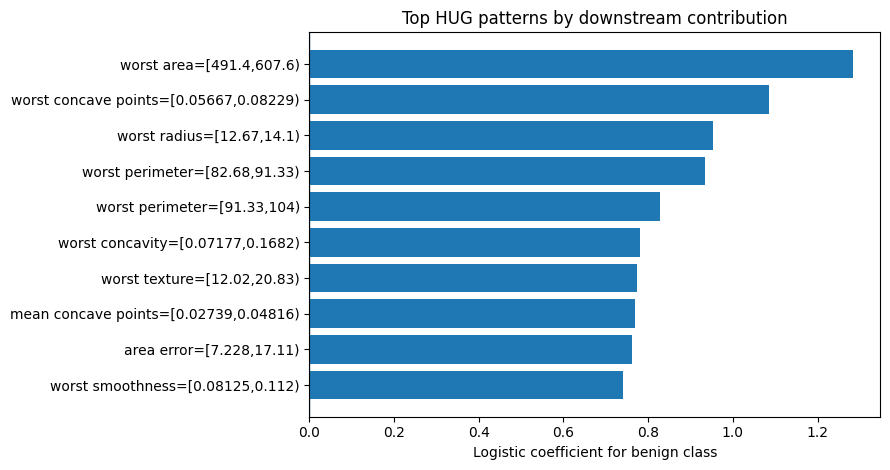

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = top_patterns.iloc[::-1]
ax.barh(plot_df["pattern"], plot_df["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("Top HUG patterns by downstream contribution")
ax.set_xlabel("Logistic coefficient for benign class")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Pick one sample

We choose the test observation closest to the decision boundary. This makes the explanation interesting because positive and negative signals both matter.

In [5]:
sample_pos = int(np.argmin(np.abs(proba - 0.5)))
sample_idx = X_test.index[sample_pos]
sample = X_test.iloc[[sample_pos]]
print(f"Selected test index: {sample_idx}")
print(f"Observed class: {data.target_names[int(y_test.iloc[sample_pos])]}")
print(f"Predicted probability of benign: {proba[sample_pos]:.3f}")
sample.T.rename(columns={sample_idx: "value"}).head(12)

Selected test index: 9
Observed class: malignant
Predicted probability of benign: 0.498


,value
mean radius,12.46000
mean texture,24.04000
mean perimeter,83.97000
mean area,475.90000
mean smoothness,0.11860
mean compactness,0.23960
mean concavity,0.22730
mean concave points,0.08543
mean symmetry,0.20300
mean fractal dimension,0.08243


## 4. Show which patterns fired

The model transforms the row into a sparse pattern matrix. A value of 1 means the row satisfies the pattern condition.

In [6]:
Z = clf.transform(sample)
fired_positions = Z.nonzero()[1]
labels = clf.get_hug_features()
coef_map = importance.set_index("pattern")["coefficient"].to_dict()
info_map = pattern_info.set_index("pattern")[["utility", "information_gain", "support"]].to_dict("index")

fired_rows = []
for j in fired_positions:
    label = labels[j]
    stats = info_map.get(label, {})
    fired_rows.append({
        "pattern": label,
        "coefficient": float(coef_map.get(label, np.nan)),
        "utility": float(stats.get("utility", np.nan)),
        "information_gain": float(stats.get("information_gain", np.nan)),
        "support": float(stats.get("support", np.nan)),
    })

fired = pd.DataFrame(fired_rows).sort_values("coefficient", ascending=False).reset_index(drop=True)
fired

,pattern,coefficient,utility,information_gain,support
0,"worst perimeter=[91.33,104)",0.828630,14.096628,0.060752,0.2
1,"worst area=[607.6,763)",0.457988,10.967580,0.047267,0.2
2,"area error=[22.64,29.89)",0.338656,10.967580,0.047267,0.2
3,"mean perimeter=[82.09,89.3)",0.322725,8.325720,0.035881,0.2
4,"worst radius=[14.1,15.74)",0.297262,8.325720,0.035881,0.2
5,"radius error=[0.2865,0.372)",0.288084,6.110136,0.026333,0.2
6,"mean radius=[11.54,12.68)",0.092733,17.806176,0.076739,0.2
7,"mean area=[408.3,497.9)",0.092733,17.806176,0.076739,0.2
8,"perimeter error=[1.543,2.057)",-0.033045,10.967580,0.047267,0.2


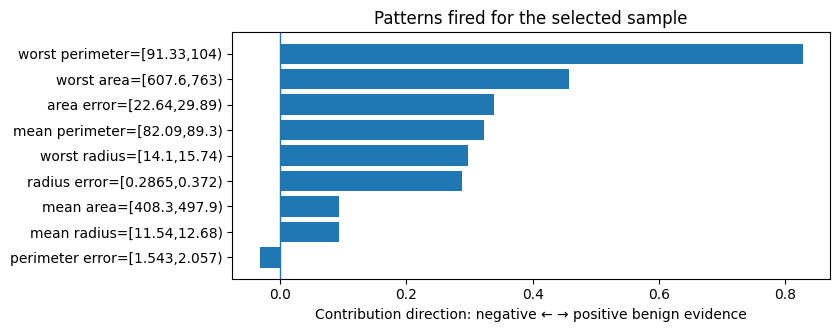

In [7]:
fig, ax = plt.subplots(figsize=(8.5, max(3, 0.38 * len(fired))))
plot_df = fired.sort_values("coefficient")
ax.barh(plot_df["pattern"], plot_df["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("Patterns fired for the selected sample")
ax.set_xlabel("Contribution direction: negative ← → positive benign evidence")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Convert pattern contributions into plain-English explanation

The explanation below uses three ingredients: the pattern condition, whether it supports the benign or malignant side, and the magnitude of the coefficient.

In [8]:
def describe_pattern(label: str, coefficient: float) -> str:
    direction = "supports the benign prediction" if coefficient >= 0 else "pushes away from the benign prediction"
    strength = "strongly" if abs(coefficient) >= 1.0 else "moderately" if abs(coefficient) >= 0.5 else "mildly"
    clean = label.replace("=", " in ")
    return f"When {clean}, this pattern {strength} {direction}."

if fired.empty:
    print("No mined pattern fired for this sample. The downstream intercept dominates this prediction.")
else:
    top_supporting = fired.sort_values("coefficient", ascending=False).head(3)
    top_opposing = fired.sort_values("coefficient", ascending=True).head(3)
    print("Plain-English explanation for the selected row:\n")
    print(f"The model estimated a {proba[sample_pos]:.1%} probability of the benign class.")
    print("\nMain supporting signals:")
    for _, row in top_supporting.iterrows():
        print(f"- {describe_pattern(row['pattern'], row['coefficient'])}")
    print("\nMain opposing signals:")
    for _, row in top_opposing.iterrows():
        if row["coefficient"] < 0:
            print(f"- {describe_pattern(row['pattern'], row['coefficient'])}")

Plain-English explanation for the selected row:

The model estimated a 49.8% probability of the benign class.

Main supporting signals:
- When worst perimeter in [91.33,104), this pattern moderately supports the benign prediction.
- When worst area in [607.6,763), this pattern mildly supports the benign prediction.
- When area error in [22.64,29.89), this pattern mildly supports the benign prediction.

Main opposing signals:
- When perimeter error in [1.543,2.057), this pattern mildly pushes away from the benign prediction.


HUG patterns are useful because they provide a transparent bridge between tabular data and model behavior. Instead of asking reviewers to inspect opaque trees or latent features, HUG-IML exposes compact rules, support levels, information gain, utility, and row-level firing behavior.